In [47]:
from langgraph.graph import StateGraph , START , END
from typing import TypedDict 
from langchain_groq import ChatGroq
from langchain_core.messages import SystemMessage, HumanMessage
import os
import sys
from pathlib import Path
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))
from config.settings import (
    GROQ_API_KEY, GROQ_MODEL,
    LLM_TEMPERATURE, LLM_MAX_TOKENS,
    SYSTEM_PROMPT,
)
from models.rules_model.rules_extractor import extract_rules

In [48]:
llm = ChatGroq(
    model       = GROQ_MODEL,
    temperature = LLM_TEMPERATURE,
    max_tokens  = LLM_MAX_TOKENS,
    api_key     = GROQ_API_KEY,
)

In [40]:
class MultiModalState(TypedDict):
    # ── Inputs ────────────────────────────────────
    query:                   str | None
    audio_path:              str | None
    image_path:              str | None

    # ── After Whisper ─────────────────────────────
    transcript:              str | None

    # ── After DistilBERT (text) ───────────────────
    text_intent:             str | None
    text_intent_embedding:   list | None

    # ── After DistilBERT (voice) ──────────────────
    voice_intent:            str | None
    voice_intent_embedding:  list | None

    # ── After CLIP + FAISS ────────────────────────
    image_embedding:         list | None
    top_3_matches:           list | None
    best_match:              dict | None

    # ── After Fusion MLP ──────────────────────────
    fusion_location:         str | None
    fusion_confidence:       float | None

    # ── After KB search ───────────────────────────
    kb_context:              str | None

    # ── LLM inputs (all three passed together) ────
    final_text_query:        str | None   # original text query
    final_voice_query:       str | None   # whisper transcript
    final_image_location:    str | None   # fusion MLP predicted location

    # ── After LLM ─────────────────────────────────
    answer:                  str | None
    error:                   str | None

In [6]:
import whisper
model = whisper.load_model("base")

In [58]:
def whisper_node(state: MultiModalState) -> MultiModalState:
    audio_path = state.get("audio_path")

    if not audio_path:
        return {
            "transcript":             None,
            "final_voice_query":      None,
            "voice_intent":           None,
            "voice_intent_embedding": None,
        }

    result     = model.transcribe(audio_path, language="en")
    transcript = result["text"].strip()

    return {
        "transcript":        transcript,
        "final_voice_query": transcript,
    }

In [11]:
from transformers import DistilBertTokenizer
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import pandas as pd
import json
import clip
import os
import pickle
import faiss
from pathlib import Path
from PIL import Image
from transformers import DistilBertTokenizer, DistilBertModel
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

# Paths
IMAGE_DIR     = Path(r"E:\Rohanta_AI_workbook\campus_chatbot\data\images")
KB_PATH       = r"E:\Rohanta_AI_workbook\campus_chatbot\data\campus_kb.json"
DISTILBERT_DIR= Path(r"E:\Rohanta_AI_workbook\campus_chatbot\models\distilbert_campus")
FAISS_DIR     = Path(r"E:\Rohanta_AI_workbook\campus_chatbot\models\clip_faiss")
MLP_DIR       = Path(r"E:\Rohanta_AI_workbook\campus_chatbot\models\fusion_mlp")
MLP_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device("cpu")

# Load KB
with open(KB_PATH, encoding="utf-8") as f:
    kb = json.load(f)
kb_lookup = {entry["name"]: entry for entry in kb}

print("Imports done")
print(f"Device: {DEVICE}")

db_tokenizer = DistilBertTokenizer.from_pretrained("distilbert-base-uncased")


Imports done
Device: cpu


In [ ]:
# Load DistilBERT base model
db_base_model = DistilBertModel.from_pretrained("distilbert-base-uncased").to(DEVICE)
db_base_model.eval()
print("DistilBERT base model loaded")

# Load rules extractor
import sys
sys.path.insert(0, r"E:\Rohanta_AI_workbook\campus_chatbot\models\rules_model")
from rules_extractor import rules_classify_intent as predict_rules
print("Rules model loaded")

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 2133.79it/s]
[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


DistilBERT base model loaded
Rules model loaded


In [16]:
import os
print(os.path.exists(r"E:\Rohanta_AI_workbook\campus_chatbot\models\rules_model\rules_extractor.py"))
print(os.listdir(r"E:\Rohanta_AI_workbook\campus_chatbot\models\rules_model"))

True
['rules_extractor.py', '__pycache__']


In [17]:
import importlib
import sys

# Remove cached version if any
if "rules_extractor" in sys.modules:
    del sys.modules["rules_extractor"]

sys.path.insert(0, r"E:\Rohanta_AI_workbook\campus_chatbot\models\rules_model")
from rules_extractor import rules_classify_intent as predict_rules

print("Rules loaded")
print(predict_rules("Where is the library?"))

Rules loaded
find_location


In [50]:
def text_distilbert_node(state: MultiModalState) -> MultiModalState:
    query = state.get("query")

    if not query:
        return {
            "text_intent":           None,
            "text_intent_embedding": None,
            "final_text_query":      None,
        }

    encoding = db_tokenizer(
        query,
        max_length     = 64,
        padding        = "max_length",
        truncation     = True,
        return_tensors = "pt",
    )

    with torch.no_grad():
        outputs = db_base_model(
            input_ids      = encoding["input_ids"].to(DEVICE),
            attention_mask = encoding["attention_mask"].to(DEVICE),
        )
        cls_emb = outputs.last_hidden_state[:, 0, :]
        cls_emb = cls_emb / cls_emb.norm(dim=-1, keepdim=True)

    return {
        "text_intent_embedding": cls_emb.cpu().numpy().squeeze().tolist(),
        "text_intent":           predict_rules(query),
        "final_text_query":      query,
    }

In [51]:
def voice_distilbert_node(state: MultiModalState) :
    transcript = state["transcript"]

    if not transcript:
        return {
            "voice_intent":           None,
            "voice_intent_embedding": None,
        }

    encoding = db_tokenizer(
        transcript,
        max_length     = 64,
        padding        = "max_length",
        truncation     = True,
        return_tensors = "pt",
    )

    with torch.no_grad():
        outputs = db_base_model(
            input_ids      = encoding["input_ids"].to(DEVICE),
            attention_mask = encoding["attention_mask"].to(DEVICE),
        )
        cls_emb = outputs.last_hidden_state[:, 0, :]
        cls_emb = cls_emb / cls_emb.norm(dim=-1, keepdim=True)

    return {
        "voice_intent_embedding": cls_emb.cpu().numpy().squeeze().tolist(),
        "voice_intent":           predict_rules(transcript),
    }

In [15]:
clip_model, clip_preprocess = clip.load("ViT-B/32", device=DEVICE)
clip_model.eval()
print("CLIP loaded")

CLIP loaded


In [22]:
def clip_node(state: MultiModalState):
    image_path = state["image_path"]

    if not image_path:
        return {"image_embedding": None}

    image = clip_preprocess(
        Image.open(image_path).convert("RGB")
    ).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        emb = clip_model.encode_image(image)
        emb = emb / emb.norm(dim=-1, keepdim=True)

    return {
        "image_embedding":    emb.cpu().numpy().squeeze().tolist(),
        "final_image_location": None,  # filled later by fusion MLP
    }

In [19]:
faiss_index = faiss.read_index(
    r"E:\Rohanta_AI_workbook\campus_chatbot\models\clip_faiss\campus_index.faiss"
)
with open(
    r"E:\Rohanta_AI_workbook\campus_chatbot\models\clip_faiss\image_records.pkl", "rb"
) as f:
    image_records = pickle.load(f)

print(f"FAISS index : {faiss_index.ntotal} vectors")
print(f"Image records: {len(image_records)}")

FAISS index : 127 vectors
Image records: 127


In [21]:
def faiss_node(state: MultiModalState) :
    image_embedding = state["image_embedding"]

    if not image_embedding:
        return {
            "top_3_matches": None,
            "best_match":    None,
        }

    query = np.array(image_embedding, dtype="float32").reshape(1, -1)
    scores, indices = faiss_index.search(query, 3)

    top_3 = []
    for score, idx in zip(scores[0], indices[0]):
        record = image_records[idx]
        top_3.append({
            "score":    round(float(score), 3),
            "category": record["category"],
            "kb_name":  record["kb_name"],
        })

    non_self = [r for r in top_3 if r["score"] < 0.999]
    best     = non_self[0] if non_self else top_3[0]

    return {
        "top_3_matches": top_3,
        "best_match":    best,
    }

In [29]:
class FusionMLP(nn.Module):
    def __init__(self, input_dim=1280, num_classes=11):
        super(FusionMLP, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        return self.network(x)

checkpoint    = torch.load(
    r"E:\Rohanta_AI_workbook\campus_chatbot\models\fusion_mlp\fusion_mlp.pt",
    map_location=DEVICE,
    weights_only=False
)

IDX_TO_CLASS  = checkpoint["idx_to_class"]
CLASS_TO_IDX  = checkpoint["class_to_idx"]

fusion_model  = FusionMLP(input_dim=1280, num_classes=11).to(DEVICE)
fusion_model.load_state_dict(checkpoint["model_state_dict"])
fusion_model.eval()

print("Fusion MLP loaded")
print(f"Classes: {IDX_TO_CLASS}")

Fusion MLP loaded
Classes: {0: 'Admissions & Registry Office', 1: 'Campus Garden & Outdoor Study Area', 2: 'Career Services Centre', 3: 'Engineering College - Main Block', 4: 'IT & Computer Lab', 5: 'Main Auditorium', 6: 'Main Cafeteria', 7: 'Main Library', 8: 'Medical & Counselling Centre', 9: 'Sports & Fitness Centre', 10: 'Student Union'}


In [30]:
# Load Fusion MLP
checkpoint = torch.load(
    r"E:\Rohanta_AI_workbook\campus_chatbot\models\fusion_mlp\fusion_mlp.pt",
    map_location=DEVICE
)

IDX_TO_CLASS = checkpoint["idx_to_class"]
CLASS_TO_IDX = checkpoint["class_to_idx"]

fusion_model = FusionMLP(input_dim=1280, num_classes=11).to(DEVICE)
fusion_model.load_state_dict(checkpoint["model_state_dict"])
fusion_model.eval()

print(f"Fusion MLP loaded")
print(f"Classes: {IDX_TO_CLASS}")

Fusion MLP loaded
Classes: {0: 'Admissions & Registry Office', 1: 'Campus Garden & Outdoor Study Area', 2: 'Career Services Centre', 3: 'Engineering College - Main Block', 4: 'IT & Computer Lab', 5: 'Main Auditorium', 6: 'Main Cafeteria', 7: 'Main Library', 8: 'Medical & Counselling Centre', 9: 'Sports & Fitness Centre', 10: 'Student Union'}


In [31]:
def fusion_mlp_node(state: MultiModalState) -> MultiModalState:
    image_emb = state["image_embedding"]
    text_emb  = state["text_intent_embedding"]
    voice_emb = state["voice_intent_embedding"]

    # Pick text embedding — prefer text, fallback to voice
    if text_emb:
        nlp_emb = text_emb
    elif voice_emb:
        nlp_emb = voice_emb
    else:
        return {"fusion_location": None, "fusion_confidence": None}

    if not image_emb:
        return {"fusion_location": None, "fusion_confidence": None}

    # Concatenate image + text embeddings → 1280-dim
    fusion_vec = np.concatenate([
        np.array(image_emb,  dtype="float32"),
        np.array(nlp_emb,    dtype="float32"),
    ])

    input_tensor = torch.tensor(fusion_vec).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        logits = fusion_model(input_tensor)
        probs  = torch.softmax(logits, dim=1).cpu().numpy().squeeze()
        pred   = probs.argmax()

    return {
        "fusion_location":    IDX_TO_CLASS[pred],
        "fusion_confidence":  round(float(probs[pred]), 3),
        "final_image_location": IDX_TO_CLASS[pred],
    }

In [32]:
def kb_search_node(state: MultiModalState):
    fusion_location = state["fusion_location"]

    if not fusion_location:
        return {"kb_context": None}

    entry = kb_lookup.get(fusion_location, {})

    if not entry:
        return {"kb_context": f"No KB entry found for {fusion_location}"}

    kb_context = f"""
Location   : {entry.get('name', 'N/A')}
Map Ref    : {entry.get('map_reference', 'N/A')}
Description: {entry.get('description', 'N/A')}
Directions : {entry.get('directions_from_entrance', 'N/A')}
Hours      : {entry.get('opening_hours', {})}
Events     : {entry.get('events', [])}
""".strip()

    return {"kb_context": kb_context}

In [52]:
def llm_node(state: MultiModalState):
    kb_context   = state["kb_context"]
    text_query   = state["final_text_query"]
    voice_query  = state["final_voice_query"]
    image_loc    = state["final_image_location"]
    confidence   = state["fusion_confidence"]

    # Build user context
    user_context = ""
    if text_query:
        user_context += f"Text query   : {text_query}\n"
    if voice_query:
        user_context += f"Voice query  : {voice_query}\n"
    if image_loc:
        user_context += f"Image shows  : {image_loc} (confidence: {confidence})\n"

    prompt = f"""You are a campus navigation assistant.

User provided the following inputs:
{user_context}

Campus Knowledge Base:
{kb_context}

Based on the above information give a helpful friendly response.
First tell what location was identified.
Then answer what the user is asking about.
If user asked about directions, give step by step directions.
If user asked about hours, state them clearly.
Keep it concise.
"""

    response = llm.invoke(prompt)
    return {"answer": response.content.strip()}

In [59]:
from langgraph.graph import StateGraph, START, END

graph = StateGraph(MultiModalState)

graph.add_node("whisper_node",          whisper_node)
graph.add_node("text_distilbert_node",  text_distilbert_node)
graph.add_node("clip_node",             clip_node)
graph.add_node("faiss_node",            faiss_node)
graph.add_node("voice_distilbert_node", voice_distilbert_node)
graph.add_node("fusion_mlp_node",       fusion_mlp_node)
graph.add_node("kb_search_node",        kb_search_node)
graph.add_node("llm_node",              llm_node)

# Parallel start
graph.add_edge(START, "whisper_node")
graph.add_edge(START, "text_distilbert_node")
graph.add_edge(START, "clip_node")

# Sequential after parallel
graph.add_edge("clip_node",             "faiss_node")
graph.add_edge("whisper_node",          "voice_distilbert_node")

# All feed into fusion
graph.add_edge("faiss_node",            "fusion_mlp_node")
graph.add_edge("voice_distilbert_node", "fusion_mlp_node")
graph.add_edge("text_distilbert_node",  "fusion_mlp_node")

# Final pipeline
graph.add_edge("fusion_mlp_node", "kb_search_node")
graph.add_edge("kb_search_node",  "llm_node")
graph.add_edge("llm_node",        END)

workflow = graph.compile()

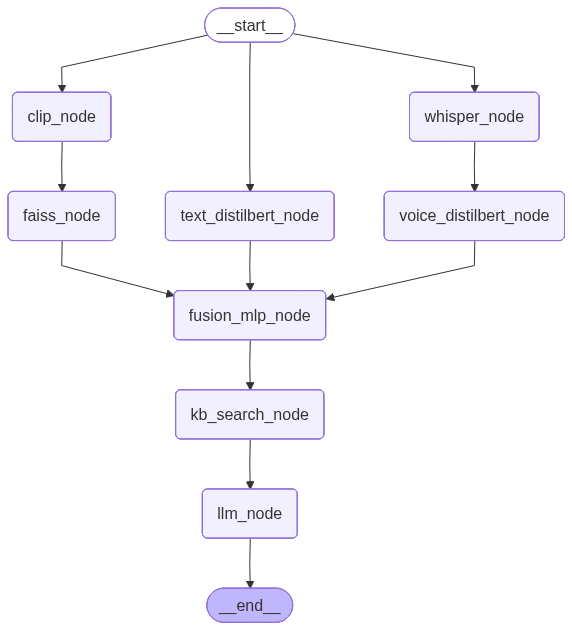

In [60]:
workflow

In [61]:
result = workflow.invoke({
    "query"      :"Where is this place and what are its opening hours?",
    "image_path" :r"E:\Rohanta_AI_workbook\campus_chatbot\data\images\library\library_01.jpg",
     "audio_path": None
})

print("=== Answer ===")
print(result["answer"])
print(f"\nFusion location : {result['fusion_location']}")
print(f"Confidence      : {result['fusion_confidence']}")
print(f"Text intent     : {result['text_intent']}")

=== Answer ===
Based on the image you provided, we've identified the location as the Main Library.

You asked, "Where is this place and what are its opening hours?"

The Main Library is located at Building A, North Campus, on the Ground to 4th Floor. It's a four-floor academic library with plenty of study spaces and resources.

As for the opening hours, the Main Library is open from:

- Monday to Thursday: 8:00 AM to 10:00 PM
- Friday: 8:00 AM to 8:00 PM
- Saturday: 9:00 AM to 6:00 PM
- Sunday: Closed

If you're looking for directions, here's how to get to the Main Library:

1. Enter through the Main Gate.
2. Walk straight for 100 metres.
3. Building A, the large red-brick building, will be on your left.
4. The library entrance is the glass-fronted door facing north.

We also have some exciting events happening at the Main Library:

- Research Skills Workshop: 28 May 2026, 2:00 PM
- Academic Writing Seminar: 3 June 2026, 10:00 AM
- Book Fair: 10 June 2026, 9:00 AM to 5:00 PM

Feel free

In [62]:
def default_state(
    query:      str | None = None,
    audio_path: str | None = None,
    image_path: str | None = None,
) -> MultiModalState:
    return {
        "query":                  query,
        "audio_path":             audio_path,
        "image_path":             image_path,
        "transcript":             None,
        "text_intent":            None,
        "text_intent_embedding":  None,
        "voice_intent":           None,
        "voice_intent_embedding": None,
        "image_embedding":        None,
        "top_3_matches":          None,
        "best_match":             None,
        "fusion_location":        None,
        "fusion_confidence":      None,
        "kb_context":             None,
        "final_text_query":       None,
        "final_voice_query":      None,
        "final_image_location":   None,
        "answer":                 None,
        "error":                  None,
    }

In [64]:
# Test 1 — Text + Image
result1 = workflow.invoke(default_state(
    query      = "Where is this place and what are its opening hours?",
    image_path = r"E:\Rohanta_AI_workbook\campus_chatbot\data\images\library\library_01.jpg",
))
print("=== Test 1: Text + Image ===")
print(f"Fusion location : {result1['fusion_location']}")
print(f"Confidence      : {result1['fusion_confidence']}")
print(f"Answer          : {result1['answer']}\n")

# Test 2 — Voice + Image
result2 = workflow.invoke(default_state(
    audio_path = r"E:\Rohanta_AI_workbook\campus_chatbot\data\audio_samples\sample_0050.wav",
    image_path = r"E:\Rohanta_AI_workbook\campus_chatbot\data\images\gym\gym_01.jpg",
))
print("=== Test 2: Voice + Image ===")
print(f"Transcript      : {result2['transcript']}")
print(f"Fusion location : {result2['fusion_location']}")
print(f"Confidence      : {result2['fusion_confidence']}")
print(f"Answer          : {result2['answer']}\n")

# Test 3 — Text + Voice + Image
result3 = workflow.invoke(default_state(
    query      = "What events are happening here?",
    audio_path = r"E:\Rohanta_AI_workbook\campus_chatbot\data\audio_samples\sample_0010.wav",
    image_path = r"E:\Rohanta_AI_workbook\campus_chatbot\data\images\cafeteria\cafeteria_01.jpg",
))
print("=== Test 3: Text + Voice + Image ===")
print(f"Text query      : {result3['final_text_query']}")
print(f"Voice query     : {result3['final_voice_query']}")
print(f"Fusion location : {result3['fusion_location']}")
print(f"Confidence      : {result3['fusion_confidence']}")
print(f"Answer          : {result3['answer']}\n")

# Test 4 — Image only
result4 = workflow.invoke(default_state(
    image_path = r"E:\Rohanta_AI_workbook\campus_chatbot\data\images\medical_center\medical_01.jpg",
))
print("=== Test 4: Image only ===")
print(f"Fusion location : {result4['fusion_location']}")
print(f"Confidence      : {result4['fusion_confidence']}")
print(f"Answer          : {result4['answer']}\n")

=== Test 1: Text + Image ===
Fusion location : Main Library
Confidence      : 0.779
Answer          : Based on the image you provided, I identified the location as the Main Library.

You asked, "Where is this place and what are its opening hours?"

The Main Library is located at Building A, North Campus, on the Ground to 4th Floor. It's a four-floor academic library with plenty of study spaces and resources.

As for the opening hours, the Main Library is open from:

- Monday to Thursday: 8:00 AM to 10:00 PM
- Friday: 8:00 AM to 8:00 PM
- Saturday: 9:00 AM to 6:00 PM
- Sunday: Closed

If you're looking for directions, here's how to get to the Main Library:

1. Enter through the Main Gate.
2. Walk straight for 100 metres.
3. Building A, the large red-brick building, will be on your left.
4. The library entrance is the glass-fronted door facing north.

Please note that there are some events happening at the Main Library, including a Research Skills Workshop on May 28th and an Academic Wri